In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm
import os

import dataset
import network

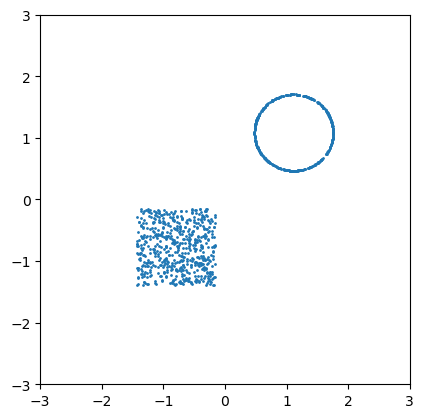

In [3]:
data = dataset.generate_training_data(1000, [1], return_full_only=True, normalize=True)
xs = data[data[:, -1] == 0, :-1]

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(xs[:, 0], xs[:, 1], s=1)
ax.set_ylim([-3, 3])
ax.set_xlim([-3, 3])
ax.set_aspect('equal')
plt.show()

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [11]:
# Diffusion parameters
# t = 0 - circles
# t = 1 - first addition of noise
# t = 500 - all noise added, ostensibly normally distributed
T = 500
betas = np.linspace(1e-4, 0.01, T)
alphas = 1 - betas
alphabar = np.cumprod(alphas)

# Training parameters
criterion = nn.MSELoss(reduction='mean')
npts = 10000 # npts*T is number of training samples
num_epochs = 10
opt = lambda params: torch.optim.Adam(params)
network_shape = [3, 100, 100, 100, 2]
batch_size = 64

# Plotting parameters
grid_points=400
vec_grid_points=20
hist_points = 10000
num_colors = max(network_shape)
colors = []
for i in range(num_colors):
    colors.append((np.random.uniform(0, 1), np.random.uniform(0, 1), np.random.uniform(0, 1)))
data_range = [-3, 3]

# Saving_parameters
checkpoint_path = 'checkpoints/nonlinears_{:04d}.pt'
animation_path = 'animation_sample_{}'
epochs_path = 'animation_epoch'
if not os.path.isdir(epochs_path):
    os.mkdir(epochs_path)
if not os.path.isdir('checkpoints'):
    os.mkdir('checkpoints')

In [12]:
net = network.Network(network_shape).to(device)
optimizer = opt(net.parameters())

In [13]:
losses = []
final_losses = []
inputs, targets = dataset.generate_training_data(npts, alphabar, normalize=True)
train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(inputs.to(device), targets.to(device)), batch_size=batch_size, shuffle=True)
full_loss = 0
for i in tqdm(range(num_epochs)):
    with torch.no_grad():
        for inputs, targets in train_loader:
            output = net(inputs)
            loss = criterion(output, targets)
            full_loss += loss.item()
    #losses.append(full_loss/npts)    
    #final_losses.append(temp.final_MSE)

  0%|          | 0/10 [00:00<?, ?it/s]

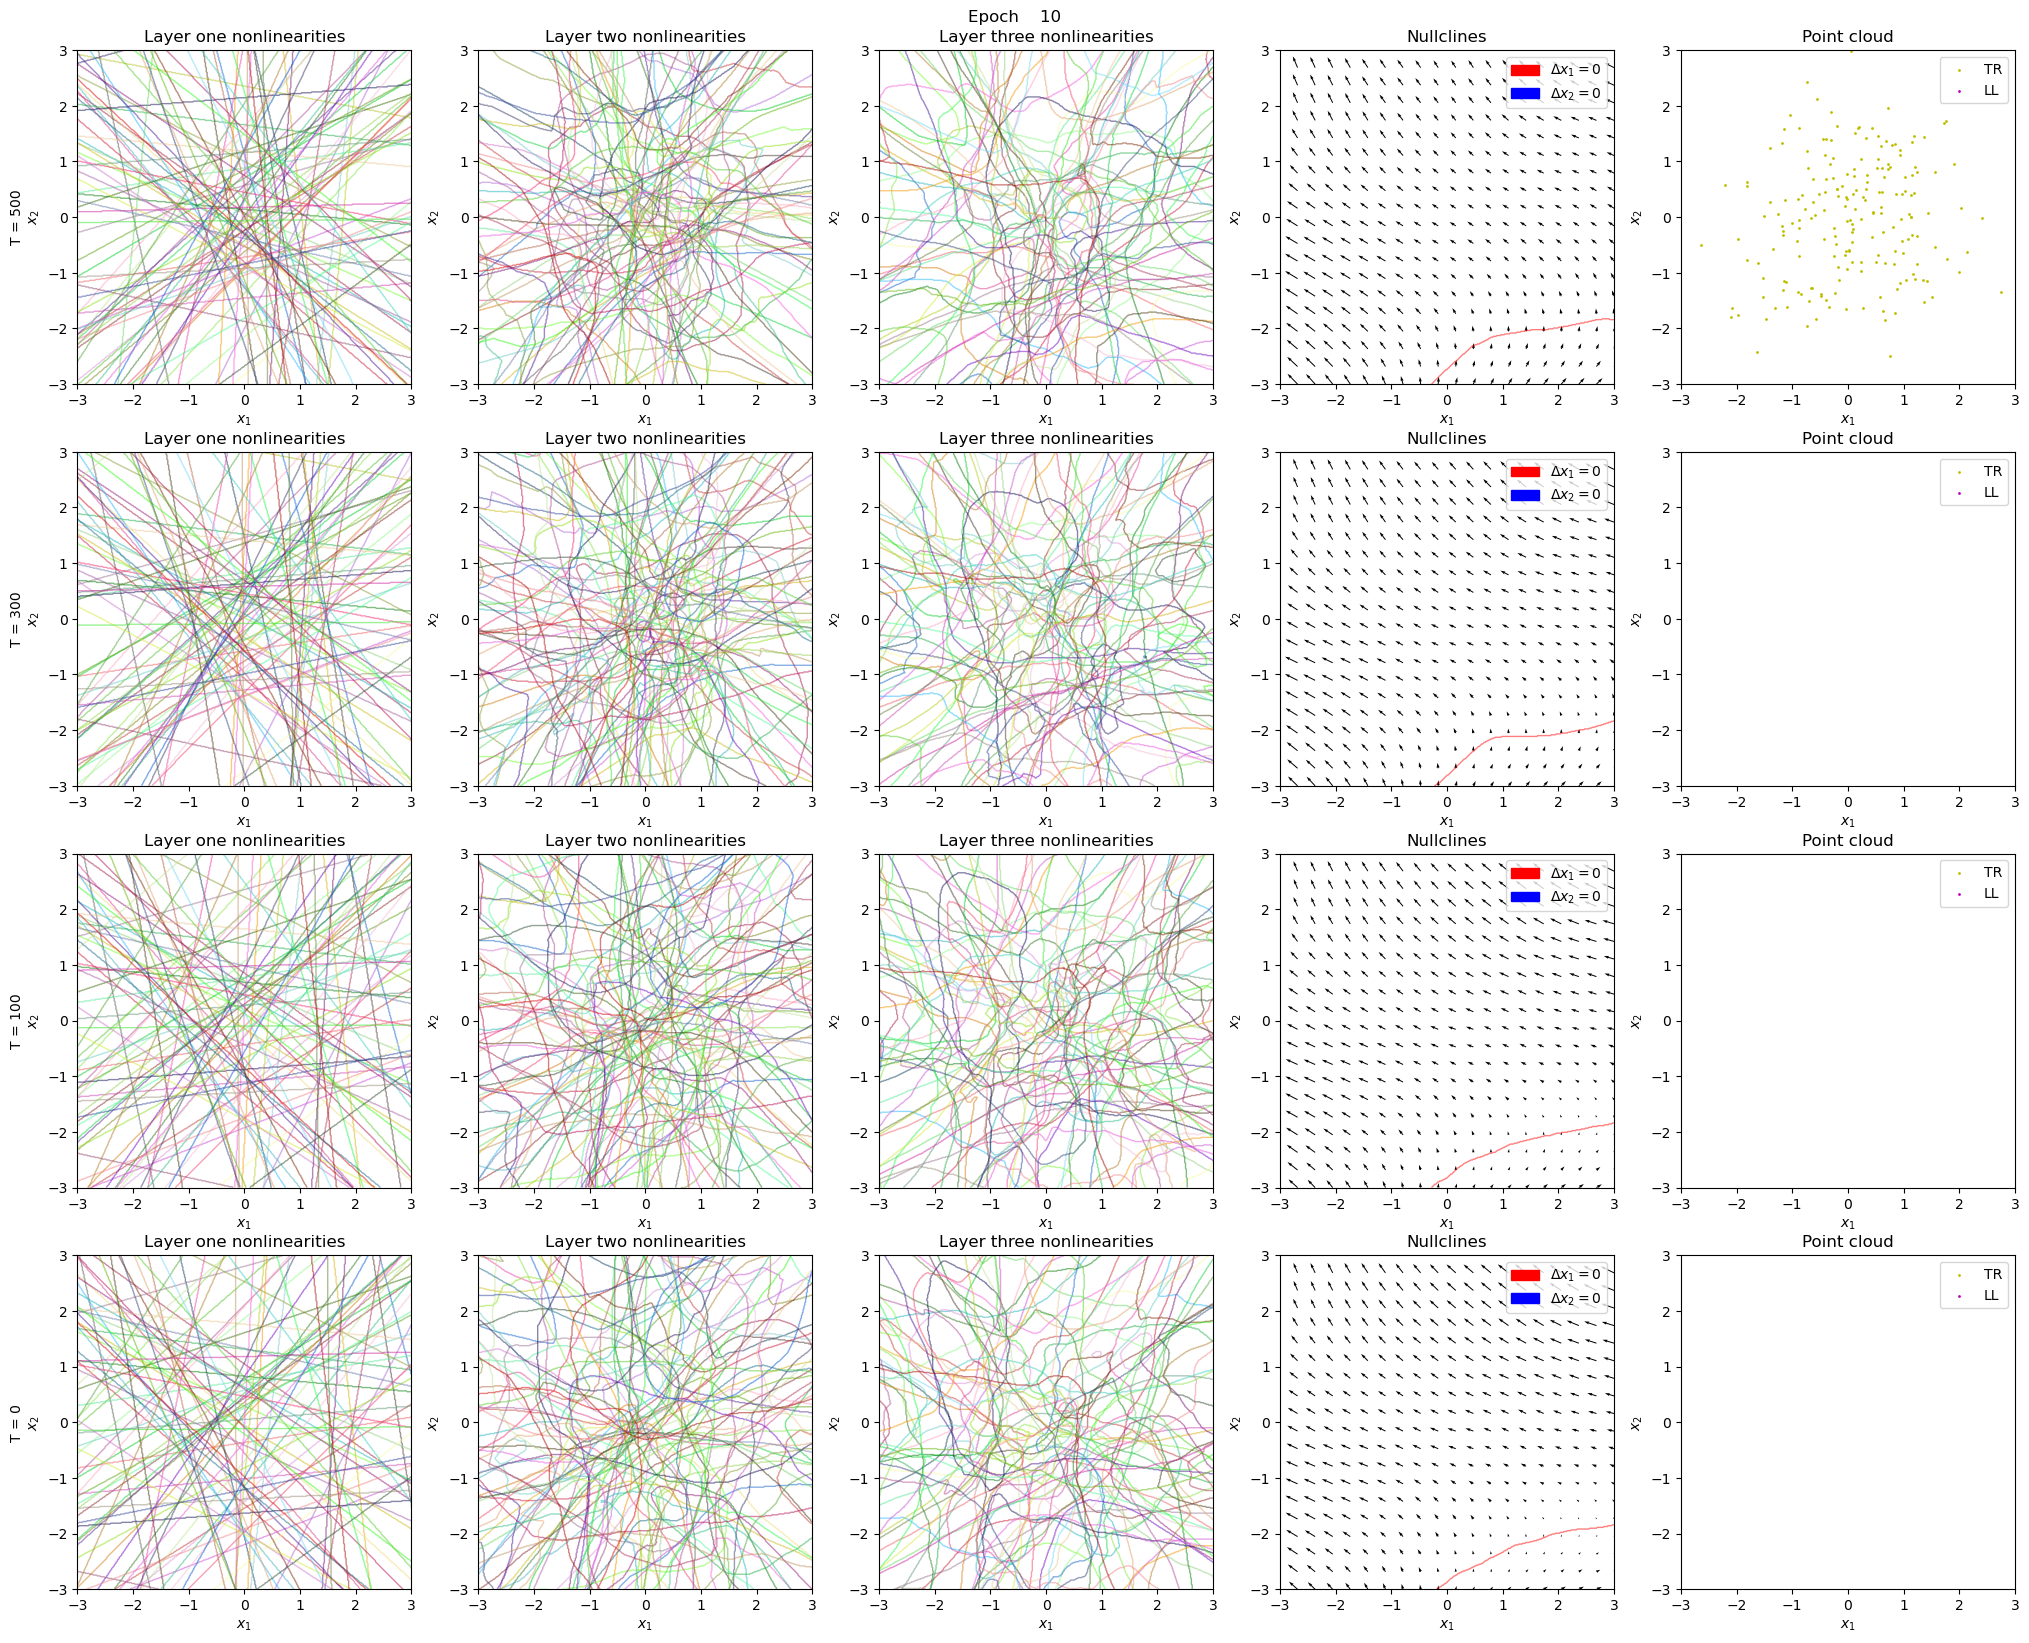

In [14]:
temp = network.Animator(net, colors, alphabar, data_range, grid_points, vec_grid_points, hist_points, hist_points)
temp.draw_small(num_epochs)